In [1]:
import os
os.environ["OMP_NUM_THREADS"] ="1"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df = df.drop("Id", axis=1)

In [8]:
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(3)

In [10]:
df = df.drop_duplicates()

In [11]:
X = df.drop("Species", axis=1)
true_labels = df["Species"]

In [12]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42)
predicted_clusters = kmeans.fit_predict(scaled_data)

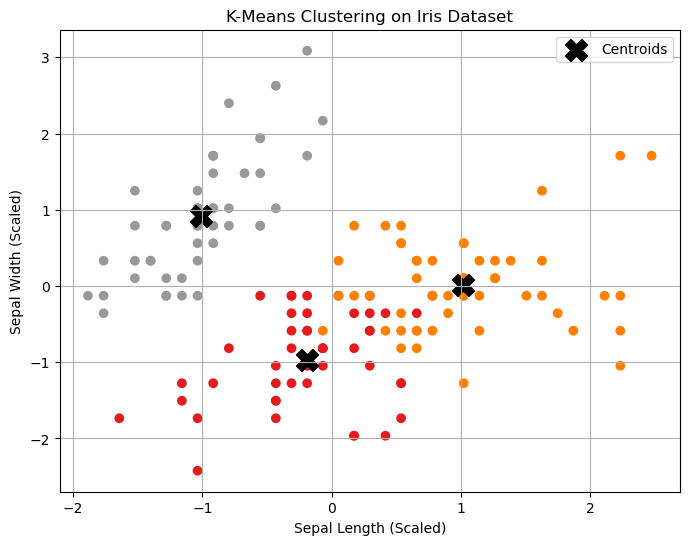

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=predicted_clusters,
    cmap="Set1",
    marker="o"
)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color="black",
    marker="X",
    s=250,
    label="Centroids"
)
plt.title("K-Means Clustering on Iris Dataset")
plt.xlabel("Sepal Length (Scaled)")
plt.ylabel("Sepal Width (Scaled)")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
#  comparing values
comparison = pd.DataFrame({
    "True Species" : true_labels,
    "Predicted Clusters" : predicted_clusters
})
comparison.head()

,True Species,Predicted Clusters
0,Iris-setosa,2
1,Iris-setosa,2
2,Iris-setosa,2
3,Iris-setosa,2
4,Iris-setosa,2


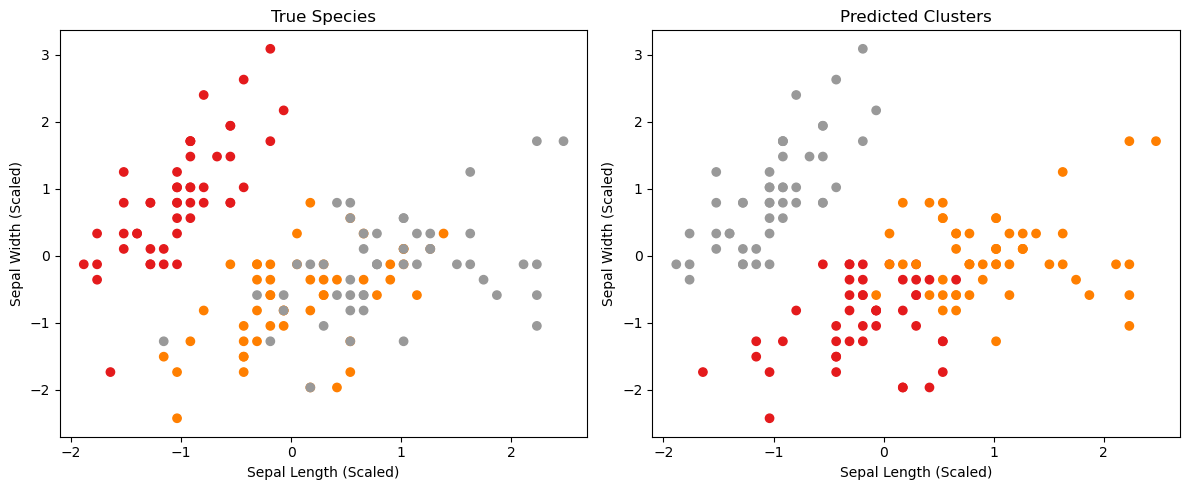

In [18]:
plt.figure(figsize=(12,5))

# True Labels
plt.subplot(1,2,1)
plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=pd.factorize(true_labels)[0],
    cmap="Set1",
    marker="o"
)
plt.title("True Species")
plt.xlabel("Sepal Length (Scaled)")
plt.ylabel("Sepal Width (Scaled)")

# Predicted Clusters
plt.subplot(1,2,2)
plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=predicted_clusters,
    cmap="Set1",
    marker="o"
)
plt.title("Predicted Clusters")
plt.xlabel("Sepal Length (Scaled)")
plt.ylabel("Sepal Width (Scaled)")

plt.tight_layout()
plt.show()